# Modelo MLP

In [1]:
import time, numpy as np, pandas as pd
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay

import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import os, random
# MLP TABULAR EN KERAS (con grid manual y métricas)
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
SEED = 42
# Carga dataset desde la carpeta raíz generada por TINTOlib
ruta_carpeta_actual = os.getcwd()
ruta_carpeta_raiz = os.path.dirname(ruta_carpeta_actual)
csv_path  = os.path.join(ruta_carpeta_raiz, "dataset", "PuntosMuestra_CR_2023_topografia.csv")
df = pd.read_csv(csv_path)

## Limpieza

In [3]:
# Quitar valores de la CATEGORIA = 2
df_filtrado = df[df["CATEGORIA"] != 2].copy()

# Re-mapear las clases a valores consecutivos desde 0
clases_unicas = sorted(df_filtrado["CATEGORIA"].unique())
mapa = {old: new for new, old in enumerate(clases_unicas)}
df_filtrado["CATEGORIA"] = df_filtrado["CATEGORIA"].map(mapa)

y = df_filtrado["CATEGORIA"]
X = df_filtrado.drop(columns=["CATEGORIA","lon","lat","year"])


## Data de entrenamiento y prueba

In [4]:
# 1) Split en train 80% / val 10% / test 10% (estratificado)
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42
)

# 2) Escalado con ajustes SOLO en train
scaler = StandardScaler()
X_train  = scaler.fit_transform(X_train).astype("float32")
X_val = scaler.transform(X_val).astype("float32")
X_test= scaler.transform(X_test).astype("float32")

num_features = X_train.shape[1]
num_classes  = np.unique(y_train).size

## Definir modelo entrenamiento

In [5]:
def build_mlp(h1=64, h2=32, dropout=0.0, lr=1e-3, wd=0.0):
    inputs = keras.Input(shape=(num_features,))
    x = layers.Dense(h1, activation="relu", kernel_regularizer=keras.regularizers.l2(wd))(inputs)
    if dropout: x = layers.Dropout(dropout)(x)
    x = layers.Dense(h2, activation="relu", kernel_regularizer=keras.regularizers.l2(wd))(x)
    if dropout: x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
    )
    return model

early_stopper = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, min_delta=1e-4, restore_best_weights=True)


## Entrenamiento y testeo

MLP Grich 1: h1=64, h2=32, dropout=0.0, lr=0.001, wd=0.0


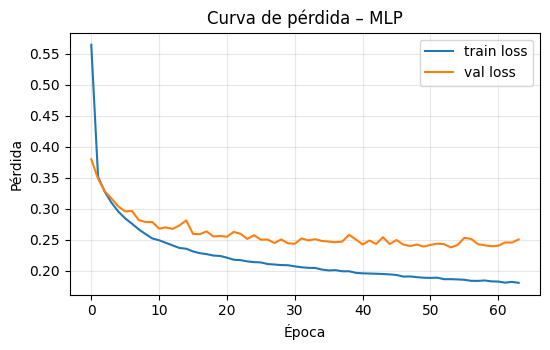

OA:0.9215 | Prec(macro):0.9030 | Recall(macro):0.8754 | F1-macro:0.8882 | val_loss:0.2504 | val_acc:0.9167
⏱ Train:21.74s | Test:0.121s (0.04 ms/muestra)

Reporte por clase:
               precision    recall  f1-score   support

           0     0.9358    0.9244    0.9301       820
           1     0.9260    0.9546    0.9401      1520
           2     0.9474    0.9643    0.9558       112
           3     0.8718    0.8644    0.8681       118
           4     0.8595    0.7591    0.8062       137
           5     0.8777    0.7857    0.8291       210

    accuracy                         0.9215      2917
   macro avg     0.9030    0.8754    0.8882      2917
weighted avg     0.9208    0.9215    0.9207      2917



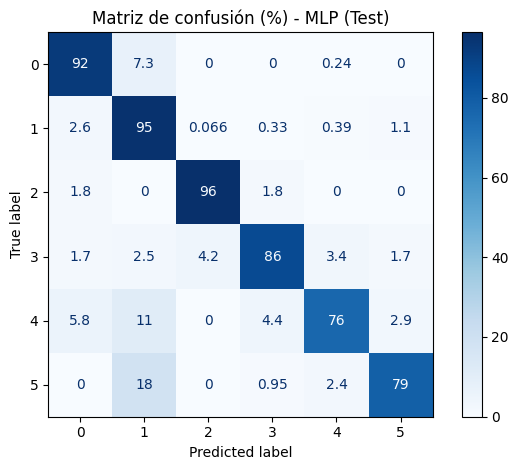

--------------------------------------------------------------------------------
MLP Grich 2: h1=64, h2=64, dropout=0.0, lr=0.001, wd=0.0


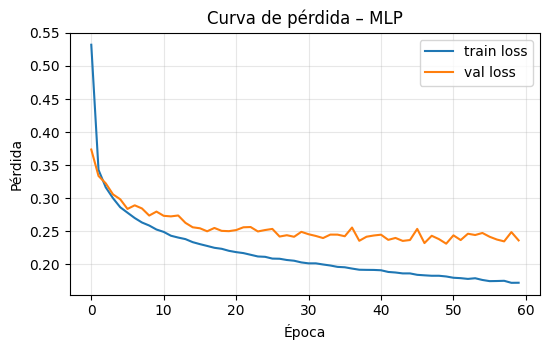

OA:0.9270 | Prec(macro):0.9019 | Recall(macro):0.8874 | F1-macro:0.8944 | val_loss:0.2362 | val_acc:0.9225
⏱ Train:18.91s | Test:0.085s (0.03 ms/muestra)

Reporte por clase:
               precision    recall  f1-score   support

           0     0.9524    0.9268    0.9394       820
           1     0.9314    0.9553    0.9432      1520
           2     0.9474    0.9643    0.9558       112
           3     0.8609    0.8390    0.8498       118
           4     0.8538    0.8102    0.8315       137
           5     0.8657    0.8286    0.8467       210

    accuracy                         0.9270      2917
   macro avg     0.9019    0.8874    0.8944      2917
weighted avg     0.9267    0.9270    0.9266      2917



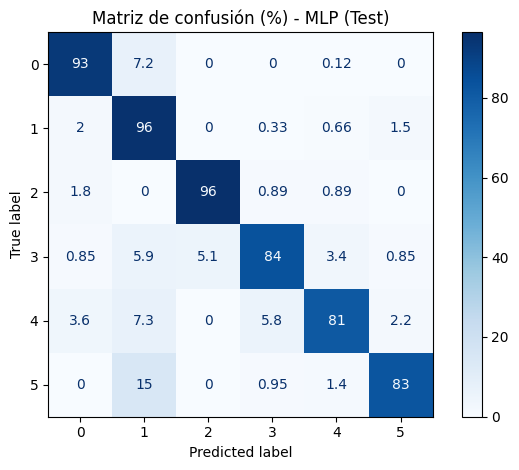

--------------------------------------------------------------------------------
MLP Grich 3: h1=128, h2=32, dropout=0.0, lr=0.001, wd=0.0


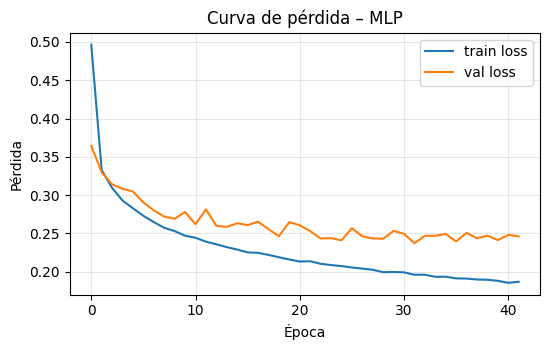

OA:0.9242 | Prec(macro):0.9047 | Recall(macro):0.8875 | F1-macro:0.8955 | val_loss:0.2462 | val_acc:0.9153
⏱ Train:13.28s | Test:0.087s (0.03 ms/muestra)

Reporte por clase:
               precision    recall  f1-score   support

           0     0.9263    0.9354    0.9308       820
           1     0.9375    0.9467    0.9421      1520
           2     0.9817    0.9554    0.9683       112
           3     0.8699    0.9068    0.8880       118
           4     0.8537    0.7664    0.8077       137
           5     0.8593    0.8143    0.8362       210

    accuracy                         0.9242      2917
   macro avg     0.9047    0.8875    0.8955      2917
weighted avg     0.9237    0.9242    0.9238      2917



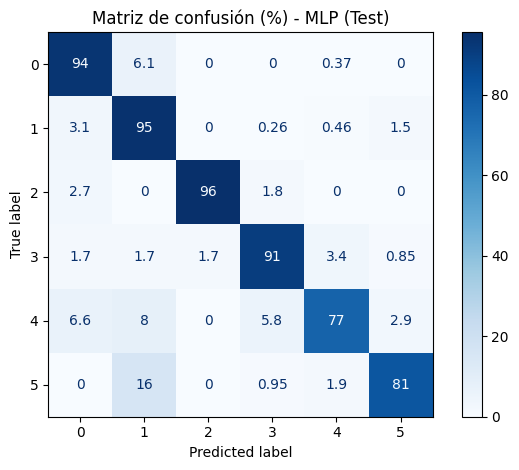

--------------------------------------------------------------------------------
MLP Grich 4: h1=128, h2=64, dropout=0.0, lr=0.001, wd=0.0


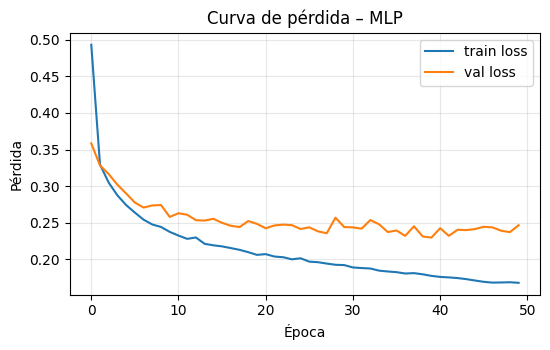

OA:0.9249 | Prec(macro):0.9066 | Recall(macro):0.8774 | F1-macro:0.8908 | val_loss:0.2466 | val_acc:0.9153
⏱ Train:16.12s | Test:0.085s (0.03 ms/muestra)

Reporte por clase:
               precision    recall  f1-score   support

           0     0.9487    0.9256    0.9370       820
           1     0.9262    0.9579    0.9418      1520
           2     0.9237    0.9732    0.9478       112
           3     0.8962    0.8051    0.8482       118
           4     0.8852    0.7883    0.8340       137
           5     0.8593    0.8143    0.8362       210

    accuracy                         0.9249      2917
   macro avg     0.9066    0.8774    0.8908      2917
weighted avg     0.9245    0.9249    0.9242      2917



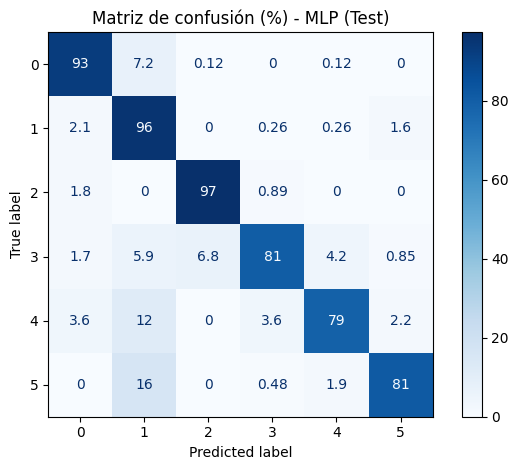

--------------------------------------------------------------------------------


In [6]:
import itertools

h1 = [64, 128]
h2 = [32, 64]
dropout = [0.0]
lr = [1e-3]
wd = [0.0] 

num = 0
for h1, h2, dropout, lr, wd in itertools.product(
        h1, h2, dropout, lr, wd):
    num = num + 1
    print(f"MLP Grich {num}: h1={h1}, h2={h2}, dropout={dropout}, lr={lr}, wd={wd}")
    
    # 3) Modelo
    #model = build_mlp(h1=64, h2=32, dropout=0.0, lr=1e-3, wd=0.0)
    model = build_mlp(h1=h1, h2=h2, dropout=dropout, lr=lr, wd=wd)
    EPOCH = 100

    # Early stopping por validación
    early_stopper = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, min_delta=1e-4, restore_best_weights=True
    )

    # 4) Entrenamiento con validación (NO se toca test aquí)
    t0 = time.perf_counter()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCH,
        batch_size=64,
        shuffle=True,
        verbose=0,
        callbacks=[early_stopper]
    )
    fit_s = time.perf_counter() - t0

    # 5) Curvas de pérdida (train y val)
    plt.figure(figsize=(5.6,3.6))
    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="val loss")
    plt.xlabel("Época"); plt.ylabel("Pérdida")
    plt.title("Curva de pérdida – MLP")
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

    # 6) Evaluación FINAL en TEST (una sola vez)
    t0 = time.perf_counter()
    y_pred = model.predict(X_test, batch_size=128, verbose=0).argmax(axis=1)
    pred_s = time.perf_counter() - t0
    ms_per_sample = (pred_s/len(y_test))*1000

    oa = accuracy_score(y_test, y_pred)
    prec, rec, f1m, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    cm  = confusion_matrix(y_test, y_pred)
    cm_row_pct = np.nan_to_num(cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100)

    print(
    f"OA:{oa:.4f} | Prec(macro):{prec:.4f} | Recall(macro):{rec:.4f} | F1-macro:{f1m:.4f} | "
    f"val_loss:{history.history.get('val_loss', [-1])[-1]:.4f} | "
    f"val_acc:{history.history.get('val_accuracy', [-1])[-1]:.4f}"
          )
    print(f"⏱ Train:{fit_s:.2f}s | Test:{pred_s:.3f}s ({ms_per_sample:.2f} ms/muestra)")
    print("\nReporte por clase:\n", classification_report(y_test, y_pred, digits=4))

    ConfusionMatrixDisplay(cm_row_pct).plot(cmap='Blues', colorbar=True)
    plt.title("Matriz de confusión (%) - MLP (Test)")
    plt.tight_layout(); plt.show()

    print("-"*80)